In [1]:
import pandas as pd
import os
import kagglehub
import matplotlib.pyplot as plt
path = kagglehub.dataset_download("zusmani/rainfall-in-pakistan")
print("Path to dataset files:", path)

path = "/kaggle/input/datasets/zusmani/rainfall-in-pakistan"
file_path = os.path.join(path, os.listdir(path)[0])
df = pd.read_csv(file_path)

Path to dataset files: /kaggle/input/datasets/zusmani/rainfall-in-pakistan


In [2]:
df = pd.read_csv(file_path)

# Cleaning (repeat for independence)
df.columns = df.columns.str.strip()
df = df.rename(columns={'Rainfall - (MM)': 'rainfall'})
df['Month'] = pd.to_datetime(df['Month'], format='%B').dt.month
df['date'] = pd.to_datetime(df[['Year','Month']].assign(DAY=1))
df = df.sort_values('date')


          rainfall         Year        Month                 date
count  1392.000000  1392.000000  1392.000000                 1392
mean     25.142392  1958.500000     6.500000  1958-12-16 05:00:00
min       0.105840  1901.000000     1.000000  1901-01-01 00:00:00
25%       9.586635  1929.750000     3.750000  1929-12-24 06:00:00
50%      19.653750  1958.500000     6.500000  1958-12-16 12:00:00
75%      33.753075  1987.250000     9.250000  1987-12-08 18:00:00
max     154.055000  2016.000000    12.000000  2016-12-01 00:00:00
std      22.239632    33.497105     3.453293                  NaN


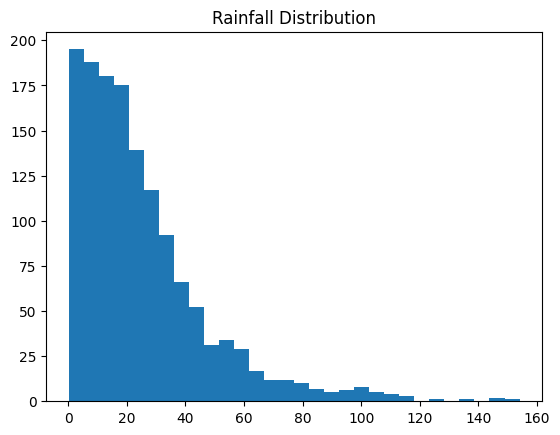

In [3]:
print(df.describe())

# Histogram
plt.figure()
plt.hist(df['rainfall'], bins=30)
plt.title("Rainfall Distribution")
plt.show()


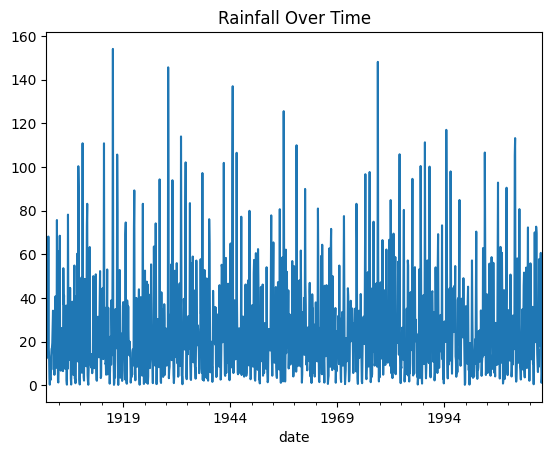

In [4]:
# Time series
plt.figure()
df.set_index('date')['rainfall'].plot(title='Rainfall Over Time')
plt.show()


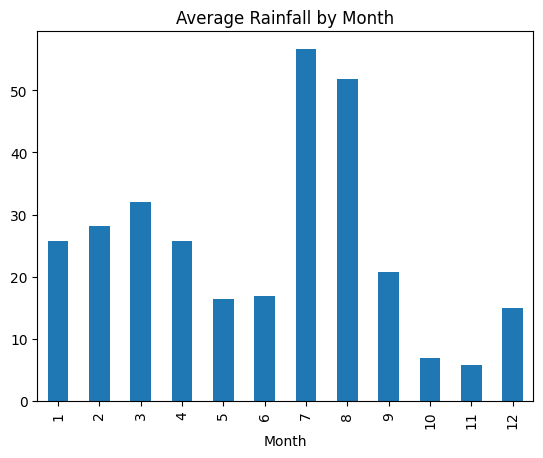

In [5]:
# Monthly pattern
monthly_avg = df.groupby('Month')['rainfall'].mean()

plt.figure()
monthly_avg.plot(kind='bar', title='Average Rainfall by Month')
plt.show()

In [6]:

# Extreme values
print("Top rainfall values:")
df.sort_values('rainfall', ascending=False).head()

Top rainfall values:


,rainfall,Year,Month,date
187,154.055,1916,8,1916-08-01
930,148.121,1978,7,1978-07-01
342,145.618,1929,7,1929-07-01
523,136.962,1944,8,1944-08-01
666,125.533,1956,7,1956-07-01
